---
title: "Gatcha games"
author: "Damien Martin"
date: "2024-11-18"
categories: [interview,puzzles]
---

# Problem

In Gatcha, you have some set number of prizes $N$ that are unique. When you play the game, you pay money to get a prize. We will assume that each prize occurs randomly, and the pool of balls is large enough so the probability remains even.

When in Japan, we played this game to get 6 golden lions, which ended up taking us 11 plays. The questions we can ask are
- What is the expected number of plays we would have?
- What is the distribution of plays we would have?

Note: In the math literature, this problem is known as the _coupon collector problem_, where you are looking to see how many coupons you would need to sort through to find the $N$ distinct coupons.

# Solution

Let's start by noting some facts about the $N=6$ game:

- The probability of collecting all 6 on turn $T$ is zero, for $T < 6$.
- If you have $n$ prizes already, there is a $n/6$ chance the next draw won't improve anything, and a $1 - n/6$ chance that you will progress to having $n+1$ prizes.

We can treat this as a transition problem. On a turn:

$$P(n | n) = n/6,  P(n+1 | n) = 1 - n/6$$



## Expected value

There is a cool shortcut for getting the expected value:

1. Let $t_n$ be the number of turns needed to go from having $n-1$ to $n$ items.
2. If you have $n$ items, the probability of getting the next item is just $1-(n-1)/6$ per draw, as above.
3. So $E(t_n) = 1/(1-(n-1)/6) = 6 / (6 - (n-1))$
4. Because each draw will jump you at most one spot, we have the expected draws $E(T) = E(T_1) + E(T_2) + ... + E(T_6)$, i.e.

$$ E(T) = \frac{6}{6 - 0} + \frac{6}{6 - 1} + \ldots + \frac{6}{6 - 5} = 6\left(\frac{1}{6} + \frac{1}{5} + \ldots + \frac{1}{1}\right) = 6 H_6 $$

where $H_6 = \sum_{i=1}^6 1/i$ is the $i$-th term in the Harmonic sum.

Numerically, this is $6 \times (2.45) = 14.7$ turns.

Moving to the distribution is a little harder!

## Distribution

We can encode the transition probabilities above as a matrix. The matrix `M[j][i]` is the probability that if you started with `i` distinct items, you end with `j` distinct items after the next draw. Clearly this is zero unless `j=i` (you draw a repeat, not increasing the number of distinct items) or `j=i+1` (you get one new item).

If at the start of a draw, the probaiblity distribution of having $i$ items is encoded as $p_i$ (where $i$ takes values from 0 to 6, inclusive), then after a draw, the probability vector is

$$ p(\text{after draw})_j = \sum_k M_{jk} p(\text{before draw})_k $$

To get what the probability is after $D$ draws, we need to apply this $D$ times, which is the same as applying the matrix `M` to our initial vector `p_0 = (1 0 0 0 0 0 0)` $D$ times. i.e. 

$$ p(\text{after D draws})_j = (M^D p_0)_j, \quad\quad p_0 = \left(\begin{array}{c}1\\0\\0\\0\\0\\0\\0\end{array}\right)$$



One thing to note: this is the _cumulative_ probability that after $D$ draws we have $j$ items, it won't be the first time we have $j$ items. Now lets code this!

In [70]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=3)

m = np.zeros(shape=(7,7))
for i in range(7):
    m[i][i] = i/6
    if i < 6:
        m[i+1][i] = 1 - i/6
print(m)

# Start off with 0 items, with probability 1
p0 = np.zeros(shape=7)
p0[0] = 1

[[0.    0.    0.    0.    0.    0.    0.   ]
 [1.    0.167 0.    0.    0.    0.    0.   ]
 [0.    0.833 0.333 0.    0.    0.    0.   ]
 [0.    0.    0.667 0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.667 0.    0.   ]
 [0.    0.    0.    0.    0.333 0.833 0.   ]
 [0.    0.    0.    0.    0.    0.167 1.   ]]


In [71]:
# Demonstrating a single transition 
# Starting with 0 items, after one selection you will have 1 items (with probability 1)
m @ p0

array([0., 1., 0., 0., 0., 0., 0.])

In [72]:
# After 2 draws:
# P(2 items) = 1 * 5/6 = 5/6 ~ 0.833
# P(1 item)  = 1 * 1/6 = 1/6 ~ 0.167
m @ m @ p0

array([0.   , 0.167, 0.833, 0.   , 0.   , 0.   , 0.   ])

In [73]:
# What is the (cumulative) probability distribution of having all 6 items after D draws?
cumulative_prob = []
p_now = p0
for _ in range(50):
    p_now = m @ p_now
    cumulative_prob.append(p_now[6])

cumulative_prob = np.array(cumulative_prob)

In [74]:
prob_frame = pd.DataFrame({'cumulative_prob': cumulative_prob})
prob_frame['turn'] = prob_frame.index + 1
prob_frame = prob_frame.reset_index(drop=True).set_index('turn')

In [75]:
prob_frame['p_all_on_this_turn'] = prob_frame['cumulative_prob'].diff().fillna(0)

<Axes: xlabel='turn'>

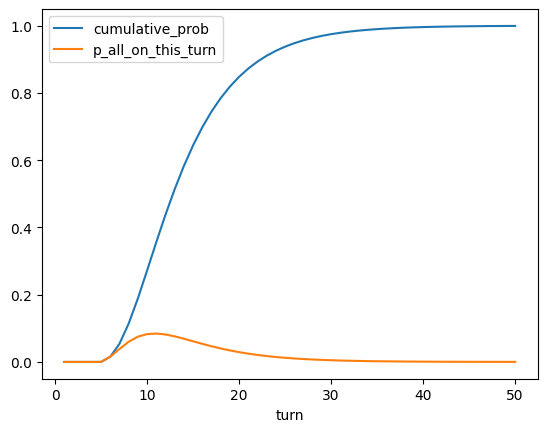

In [76]:
prob_frame.plot()

In [77]:
prob_frame.head(12)

,cumulative_prob,p_all_on_this_turn
turn,,
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000000,0.000000
4,0.000000,0.000000
5,0.000000,0.000000
6,0.015432,0.015432
7,0.054012,0.038580
8,0.114026,0.060014
9,0.189043,0.075017


So we see in the case of the 6 lions, the probability that we would get all 6 lions on exactly the 11th draw was 8.4%, and the probability that we would play 11 games or fewer was 35.6%. Note that 11 games is the most likely single outcome (earlier than this you needed to be very lucky, later than this and the probability starts dropping because you succeeded in earlier rounds).

We can also check our (approximate, because of early stopping) result by looking at the expected value vs our exact computation above:

In [78]:
prob_frame.reset_index().assign(e_comp = lambda x: x.turn * x.p_all_on_this_turn)['e_comp'].sum()

14.663079947596907

Note it is slightly lower than our calculation above (and this is expected, since we cut off the long tail by having the game "give up" after 50 draws).

### Distribution via more direct simulation

The matrix trick was cute, but I often like to check my results by a more direct simulation. The simulation has statistical noise, and won't scale well, but looking at an example with 6 prizes gives me confidence the above solution is reliable, and then I can scale that solution to N $\gg$ 6.

In [79]:
def get_new_item_in_draw(n_have: int, n_total: int) -> bool:
    p_new_item = 1-n_have / n_total
    return np.random.random() < p_new_item


def num_draws_until_n_items(n_total: int) -> int:
    n_have = 0
    draws = 0
    while n_have < n_total:
        draws += 1
        n_have += get_new_item_in_draw(n_have=n_have, n_total=n_total)
    return draws


def simulation(items: int, num_sims: int):
    sim_results = [
        num_draws_until_n_items(n_total=items)
        for _ in range(num_sims)
    ]
    return np.array(sim_results)

In [80]:
results = simulation(items=6, num_sims=10_000)

In [81]:
# What is the average number of games that need to be played?
results.mean()

14.7794

In [82]:
# What is the distribution?
from collections import Counter

pd.DataFrame(sorted([(k, v) for k, v in dict(Counter(results)).items()]), columns=['turn', 'games_ended']).assign(
    frac_ended = lambda x: x.games_ended/x.games_ended.sum()
).head(n=10)

,turn,games_ended,frac_ended
0,6,142,0.0142
1,7,372,0.0372
2,8,591,0.0591
3,9,771,0.0771
4,10,840,0.0840
5,11,844,0.0844
6,12,774,0.0774
7,13,755,0.0755
8,14,691,0.0691
9,15,621,0.0621


We can see that 8.45% of games ended after turn 11, matching the approach used by the transition matrix.